In [1]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [2]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "test" / "images"
test_labels = root / "test" / "labels"
print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


In [3]:
RESIZED_IMG_SIZE=400

In [4]:
import os
import cv2
import numpy as np

def load_detection_data(img_dir, label_dir, img_size=(RESIZED_IMG_SIZE, RESIZED_IMG_SIZE)):
    images = []
    boxes = [] # Tutaj trafią tylko współrzędne [x, y, w, h]

    file_names = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

    for file_name in file_names:
        # 1. Wczytaj obraz
        img_path = os.path.join(img_dir, file_name.replace('.txt', '.jpg'))
        img = cv2.imread(img_path)
        if img is None: continue
        
        h_img, w_img, _ = img.shape
        
        # 2. Wczytaj etykietę (zakładamy format: class x_center y_center w h)
        with open(os.path.join(label_dir, file_name), 'r') as f:
            line = f.readline().split()
            if not line: continue
            
            # Pomijamy klasę (line[0]), bo ten model szuka tylko dłoni ogólnie
            # Dane w pliku są zazwyczaj znormalizowane. Jeśli nie są - podziel przez w_img/h_img
            cx, cy, w, h = map(float, line[1:]) 
            
            # Przeliczamy z center (środek) na top-left (lewy górny róg) - łatwiej się to wycina
            x = cx - (w / 2)
            y = cy - (h / 2)
            
            boxes.append([x, y, w, h])

        # 3. Resize obrazu do formatu wejściowego sieci
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        images.append(img / 255.0)

    return np.array(images), np.array(boxes)

# Wczytanie danych
X_train, Y_train = load_detection_data(train_images, train_labels)

X_val, Y_val = load_detection_data(test_images, test_labels)

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_locator_model():
    # 1. Backbone (kręgosłup sieci) - MobileNetV2 bez ostatnich warstw
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(RESIZED_IMG_SIZE, RESIZED_IMG_SIZE, 3),
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False # Zamrażamy na początek

    # 2. Head (głowa sieci) - nasza własna część regresyjna
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x) # Zapobiega overfittingowi
    x = layers.Dense(64, activation='relu')(x)
    
    # Wyjście: 4 wartości [x, y, w, h]
    # Sigmoid wymusza wynik w zakresie 0-1
    outputs = layers.Dense(4, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

detector = build_locator_model()

2026-01-30 16:02:38.837241: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 16:02:38.876222: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 16:02:52.627240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/tmp/ipykernel_1045/2762523235.py:6: UserWarning: `input_shape` is u

In [6]:
# Kompilacja
detector.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',      # Minimalizujemy błąd odległości
    metrics=['mae', 'accuracy']  # Średni błąd bezwzględny (dla czytelności)
)

# Callbacks - przydatne narzędzia
callbacks = [
    # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'hand_detector_best.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
    # Zmniejsz learning rate, gdy sieć przestanie się uczyć
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3
    )
]

# Start treningu
history = detector.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,       # Regresja wymaga zazwyczaj więcej epok niż klasyfikacja
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/50


2026-01-30 16:03:14.428313: I external/local_xla/xla/service/service.cc:163] XLA service 0x7734bc011310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 16:03:14.428363: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2026-01-30 16:03:14.573034: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-30 16:03:15.281983: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-01-30 16:03:15.430204: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-30 16:03:15.43083

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4414 - loss: 0.0227 - mae: 0.1208

2026-01-30 16:03:48.455148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 16:03:48.711038: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 16:03:54.184042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 16:03:54.339301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 16:03:54.496308: E external/local_xla/xla/stream_

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4479 - loss: 0.0221 - mae: 0.1193  

2026-01-30 16:03:58.827631: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-30 16:03:59.201779: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1217', 100 bytes spill stores, 100 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5067 - loss: 0.0175 - mae: 0.1057 - val_accuracy: 0.5238 - val_loss: 0.0104 - val_mae: 0.0850 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5705 - loss: 0.0114 - mae: 0.0850 - val_accuracy: 0.5238 - val_loss: 0.0079 - val_mae: 0.0714 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6107 - loss: 0.0083 - mae: 0.0718 - val_accuracy: 0.5238 - val_loss: 0.0067 - val_mae: 0.0620 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6544 - loss: 0.0072 - mae: 0.0656 - val_accuracy: 0.5952 - val_loss: 0.0052 - val_mae: 0.0547 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6678 - loss: 0.0059 - mae: 0.0590 - val_accuracy: 0.6190 - val_loss: 0.0039 - val_mae: 0.0473 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7013 - loss: 0.0046 - mae: 0.052

In [12]:
score = detector.evaluate(X_val, Y_val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9286 - loss: 8.5315e-04 - mae: 0.0222 


In [13]:
def crop_hand(image_path, model):
    # 1. Przygotuj obraz
    original_img = cv2.imread(image_path)
    img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (RESIZED_IMG_SIZE, RESIZED_IMG_SIZE)) / 255.0
    input_tensor = np.expand_dims(img_resized, axis=0)

    # 2. Predykcja ramki
    box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
    
    # 3. Przelicz na piksele
    h_orig, w_orig, _ = original_img.shape
    x = int(box[0] * w_orig)
    y = int(box[1] * h_orig)
    w = int(box[2] * w_orig)
    h = int(box[3] * h_orig)

    # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
    x = max(0, x)
    y = max(0, y)
    
    # 4. Wycięcie (Crop)
    # Dodajemy mały margines (padding), żeby nie uciąć palców
    padding = 20
    crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
    
    return crop, (x, y, w, h)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


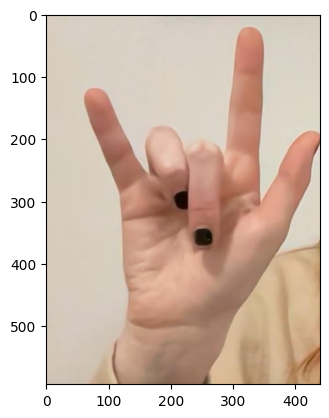

In [14]:
# Test

import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")

cropped_img, coords = crop_hand("./Sign Language Detection/babeczka/test/images/iloveyou_1f4c00c4-7679-11ed-bb1e-1e08bc6ed8a6_jpg.rf.e6b72a4127ff5544f3bd78317ca11b0e.jpg", detector)

if cropped_img.size > 0:
    cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)

In [10]:
# import os

# LABELS_DIR = "./Sign Language Detection/babeczka/test/labels"
# IMAGES_DIR = "./Sign Language Detection/babeczka/test/images"

# for filename in os.listdir(LABELS_DIR):
#     if not filename.endswith(".txt"):
#         continue

#     label_path = os.path.join(LABELS_DIR, filename)

#     # Check if label file is empty or only whitespace
#     with open(label_path, "r") as f:
#         content = f.read().strip()

#     if content == "":
#         image_name = os.path.splitext(filename)[0] + ".jpg"
#         image_path = os.path.join(IMAGES_DIR, image_name)

#         if os.path.exists(image_path):
#             os.remove(image_path)
#             print(f"Deleted image: {image_path}")
#         else:
#             print(f"Image not found: {image_path}")

#         # OPTIONAL: delete the empty label file itself
#         os.remove(label_path)
#         print(f"Deleted label: {label_path}")
